(ch:ml-cancer)=
# 분류 평가: 유방암 데이터셋

이 장에서는 scikit-learn에 내장된 유방암 데이터셋을 이용하여 이진 분류 모델을 만든다. 목표는 분류 모델을 훈련하는 것뿐 아니라, 정확도, 혼동 행렬, 정밀도, 재현율을 함께 해석하는 것이다.

## 데이터셋

이 데이터셋은 세포핵 이미지에서 계산한 여러 수치형 특성을 바탕으로 종양이 악성인지 양성인지 분류하는 예제 데이터셋이다.

- 입력 특성: 세포핵의 반지름, 질감, 둘레, 면적, 오목함 등 30개 수치형 특성
- 타깃: malignant 또는 benign

이 예제는 분류 모델과 평가 지표를 배우기 위한 교육용 예제이며, 실제 의학적 진단을 대신할 수 없다.

필요한 라이브러리와 scikit-learn의 유방암 데이터셋을 불러온다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

sns.set_theme(style="whitegrid")

`load_breast_cancer(as_frame=True)`를 사용하여 데이터를 데이터프레임 형태로 불러온다.

In [2]:
cancer = load_breast_cancer(as_frame=True)

X = cancer.data
y = cancer.target
target_names = cancer.target_names

cancer_df = X.copy()
cancer_df["diagnosis"] = pd.Categorical.from_codes(y, target_names)
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


데이터의 크기와 타깃 클래스의 개수를 확인한다.

In [3]:
cancer_df.shape

(569, 31)

In [4]:
cancer_df["diagnosis"].value_counts()

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

입력 특성은 모두 수치형이다. 여기서는 지표 해석이 잘 보이도록 전체 30개 특성 중 일부만 선택해서 먼저 모델을 만든다.

In [5]:
X.dtypes.value_counts()

float64    30
Name: count, dtype: int64

## 주요 특성 선택

전체 특성을 모두 사용하면 성능이 매우 높게 나올 수 있다. 여기서는 설명을 위해 서로 성격이 조금 다른 네 개의 특성만 사용한다.

In [6]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean concavity",
    "mean symmetry",
]

cancer_df[selected_features + ["diagnosis"]].head()

,mean radius,mean texture,mean concavity,mean symmetry,diagnosis
0,17.99,10.38,0.3001,0.2419,malignant
1,20.57,17.77,0.0869,0.1812,malignant
2,19.69,21.25,0.1974,0.2069,malignant
3,11.42,20.38,0.2414,0.2597,malignant
4,20.29,14.34,0.1980,0.1809,malignant


선택한 특성의 클래스별 분포를 상자그림으로 비교한다. 어떤 특성은 두 클래스의 분포가 꽤 다르고, 어떤 특성은 서로 겹치는 부분이 있다.

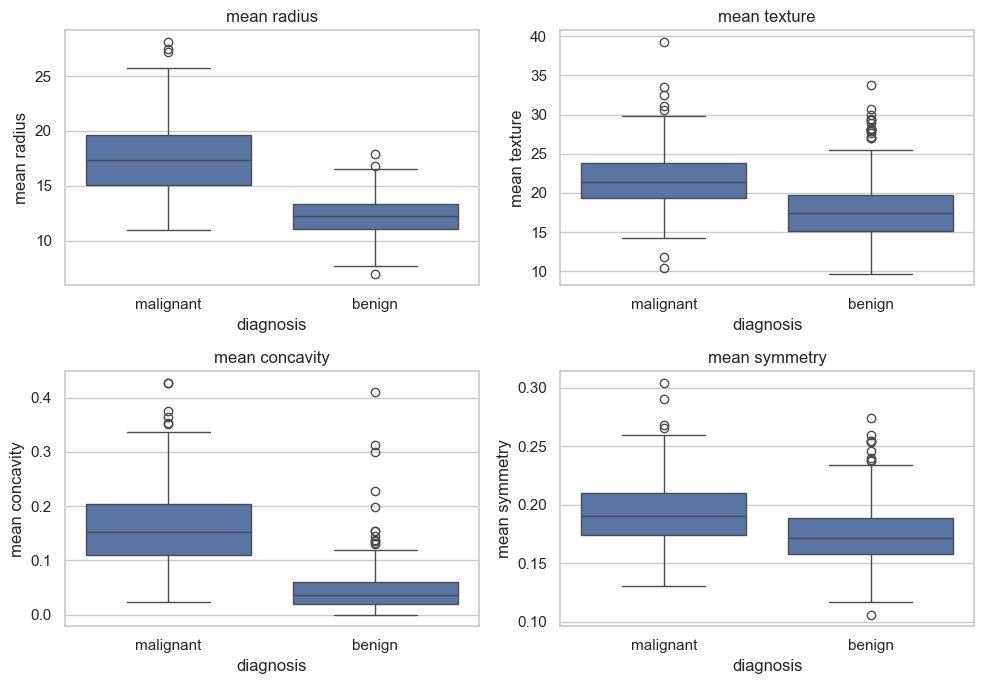

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

for feature, ax in zip(selected_features, axes):
    sns.boxplot(data=cancer_df, x="diagnosis", y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("diagnosis")

plt.tight_layout()
plt.show()

반지름과 오목함을 산점도로 그려 두 클래스가 어느 정도 구분되는지 확인한다.

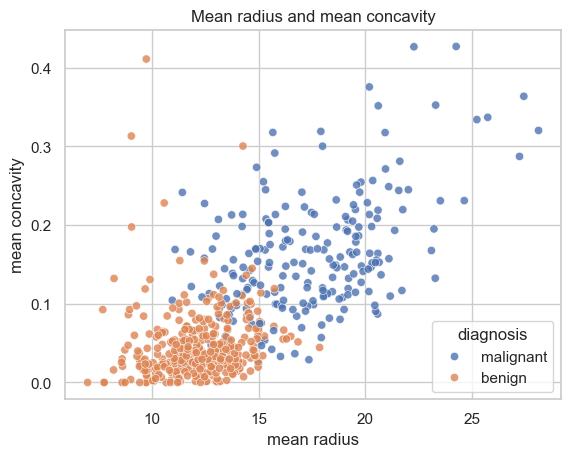

In [8]:
sns.scatterplot(
    data=cancer_df,
    x="mean radius",
    y="mean concavity",
    hue="diagnosis",
    alpha=0.8,
)
plt.title("Mean radius and mean concavity")
plt.show()

## 모델 훈련

선택한 네 개 특성을 사용하여 로지스틱 회귀 모델을 훈련한다. 타깃 클래스의 비율을 유지하기 위해 `stratify` 옵션을 사용한다.

In [9]:
X_selected = cancer_df[selected_features]
y_diagnosis = cancer_df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_diagnosis,
    test_size=0.3,
    random_state=42,
    stratify=y_diagnosis,
)

특성마다 값의 범위가 다르므로 표준화를 적용한다. 표준화 기준은 훈련셋에서 계산하고 테스트셋에는 같은 기준을 적용한다.

In [10]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=selected_features,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=selected_features,
    index=X_test.index,
)

In [11]:
cancer_model = LogisticRegression(max_iter=1000)
cancer_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

테스트셋에 대해 예측하고 정확도를 계산한다. 정확도는 전체 테스트 샘플 중 맞게 예측한 비율이다.

In [12]:
y_pred = cancer_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.935672514619883

## 혼동 행렬

혼동 행렬은 실제 클래스와 예측 클래스를 함께 보여준다. 이진 분류에서는 어떤 종류의 실수가 발생했는지 확인하는 데 특히 유용하다.

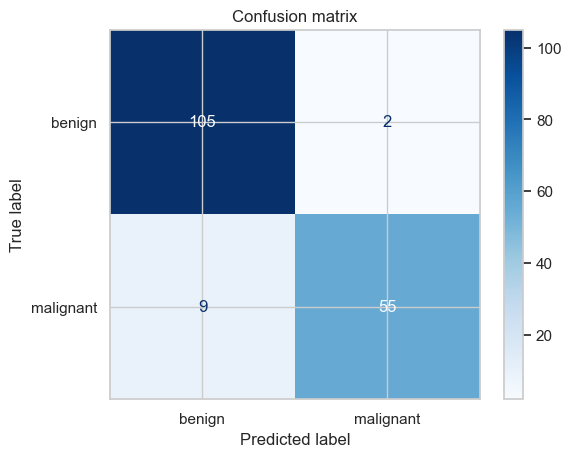

In [13]:
labels = cancer_model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

## 정밀도와 재현율

정밀도는 모델이 어떤 클래스로 예측한 것 중 실제로 맞은 비율이다. 재현율은 실제 그 클래스인 샘플 중 모델이 찾아낸 비율이다.

의료 데이터 예제에서는 두 종류의 실수의 의미가 다를 수 있다. 따라서 정확도 하나만 보기보다 정밀도와 재현율을 함께 확인해야 한다.

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      benign       0.92      0.98      0.95       107
   malignant       0.96      0.86      0.91        64

    accuracy                           0.94       171
   macro avg       0.94      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171



## 전체 특성과 비교

이번에는 전체 30개 특성을 사용하여 같은 모델을 훈련한다. 주요 특성 몇 개만 사용했을 때와 전체 특성을 사용했을 때 성능이 어떻게 달라지는지 비교한다.

In [15]:
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X,
    y_diagnosis,
    test_size=0.3,
    random_state=42,
    stratify=y_diagnosis,
)

all_scaler = StandardScaler()
X_all_train_scaled = all_scaler.fit_transform(X_all_train)
X_all_test_scaled = all_scaler.transform(X_all_test)

cancer_all_model = LogisticRegression(max_iter=1000)
cancer_all_model.fit(X_all_train_scaled, y_all_train)

y_all_pred = cancer_all_model.predict(X_all_test_scaled)
all_accuracy = accuracy_score(y_all_test, y_all_pred)

pd.DataFrame(
    {
        "model": ["selected features", "all features"],
        "accuracy": [accuracy, all_accuracy],
    }
)

,model,accuracy
0,selected features,0.935673
1,all features,0.970760


## 정리

이번 장에서는 유방암 데이터셋으로 이진 분류 모델과 평가 지표를 살펴보았다.

- 이진 분류는 두 클래스 중 하나를 예측하는 문제이다.
- 정확도는 전체적으로 얼마나 맞혔는지를 보여준다.
- 혼동 행렬은 모델이 어떤 실수를 했는지 보여준다.
- 정밀도는 예측한 것 중 얼마나 맞았는지를 나타낸다.
- 재현율은 실제 해당 클래스 중 얼마나 찾아냈는지를 나타낸다.
- 문제의 맥락에 따라 정밀도와 재현율 중 더 중요하게 볼 지표가 달라질 수 있다.

## 연습문제

**문제 1**

`mean radius`, `mean texture` 두 특성만 사용하여 모델을 훈련해 보아라. 네 개 특성을 사용했을 때와 성능이 어떻게 달라지는가?

**문제 2**

혼동 행렬에서 모델이 어떤 종류의 실수를 했는지 설명해 보아라.

**문제 3**

`classification_report()`에서 malignant와 benign의 정밀도와 재현율을 비교해 보아라. 두 클래스의 지표가 같은가, 다른가?